Monte carlo simulatie voor de depressiegraaf

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numba import njit

In [2]:
#initializing the graph, hard coded from the board
#we use the connection matrix defined during the yap session
"""
1: Concentratie
2: Traag/Zenuwachtig
3: Suicidaal
4: Laag zelfbeeld
5: Weinig interesse
6: Neerslachtig
7: Slechte slaap
8: Moe
9: Eetstoornis

We doen verbindings_matrix[i,j] is van i naar j
"""
verbindings_matrix = [[0,6,0,0,0,0,0,0,0], 
                      [6,0,0,1,0,0,4,0,0], 
                      [0,0,0,8,3,0,9,0,0], 
                      [0,0,3,7,5,2,1,0,2], 
                      [0,2,1,0,3,0,0,0,1], 
                      [0,2,1,2,7,3,0,0,2], 
                      [0,0,0,1,0,0,1,10,0], 
                      [7,2,0,3,4,4,-3,0,0], 
                      [1,4,0,4,0,0,2,2,1]]
verbindings_matrix = np.array(verbindings_matrix)

extern_veld = [0,0,0,0,0,0,0,0,0] #naar wens aan te passen, kan normaal ook over gesweept worden
extern_veld = np.array(extern_veld)
model_params = [verbindings_matrix, extern_veld]

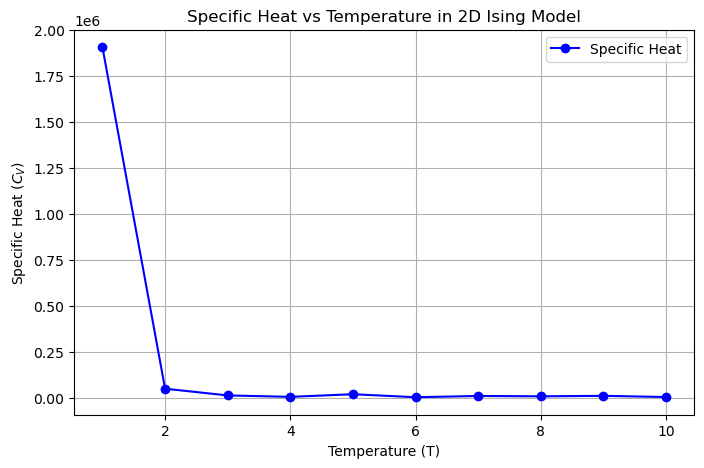

In [3]:
# Monte carlo simulatie met credits naar prof. Enrico Carlon, aangepast om op de depressiegraaf te runnen

#TODO: @njit weer fixen zodat de code niet meer insane traag is
def initialize_lattice(L):
    """Initialize an LxL lattice with random spins (+1 or -1)."""
    return np.random.choice([-1, 1], size=(L))
@njit
def compute_energy(lattice, intern, extern):
    """Compute the total energy of the lattice."""
    energy = 0
    L = np.size(lattice)
    diag_counter = np.ones(L) #to prevent double counting the diagonal
    for i in range(L):
        external = lattice[i]*extern[i]
        internal = 0
        for j in range(L):
            if i != j:
                internal += lattice[i]*lattice[j]*intern[i][j]
            elif diag_counter[i] == 1:
                internal += lattice[i]*lattice[j]*intern[i][j]
                diag_counter[i] += 1
        energy += external + internal        
    return energy
@njit
def metropolis_step(lattice, beta, intern, extern):
    """Perform one Metropolis update step."""
    L = len(lattice)
    dE = 0
    new_latice = lattice.copy()
    initial_energy = compute_energy(lattice, intern, extern)
    for _ in range(L):
        i = np.random.randint(0, L)
        S = new_latice[i]
        new_latice[i] = -S
        new_E = compute_energy(new_latice, intern, extern)
        delta_E = new_E - initial_energy
        prob = np.exp(beta*delta_E)
        if delta_E < 0 or np.random.rand() < prob:
            lattice[i] *= -1
            dE += delta_E
    return dE
def simulate_ising(L, T, sweeps, equilib_sweeps, parameters):
    intern = parameters[0]
    extern = parameters[1]
    """Simulate the Ising model and compute average energy & energy squared"""
    beta = 1.0 / T
    lattice = initialize_lattice(L)
    #lattices = []
### Precompute an array with the possible values of the energy change
### and Metropolis probabilities
    E = compute_energy(lattice, intern, extern)
    for _ in range(equilib_sweeps):
        E += metropolis_step(lattice, beta, intern, extern)
    E_total=E;E2_total=E**2
    for _ in range(sweeps):
        E += metropolis_step(lattice, beta, intern, extern)
        E_total += E
        E2_total += E**2
    E_avg=E_total/sweeps;E2_avg=E2_total/sweeps
    return E_avg, E2_avg, lattice
def compute_model(parameters, L, T_values, sweeps, equilib_sweeps=100):
    """Compute specific heat over a range of temperatures."""
    C_V_values = []
    lattices = []
    for T in T_values:
    # print(f"T: {T:.2f}")
        E_avg, E2_avg, latc = simulate_ising(L, T, sweeps, equilib_sweeps, parameters)
        C_V = (E2_avg - E_avg**2) / (T**2 * L**2)
        C_V_values.append(C_V)
        lattices.append(latc)
    return C_V_values, np.array(lattices)
### Simulation Parameters
L = 9 # Lattice size
T_values = [1,2,3,4,5,6,7,8,9,10] # Temperature range
sweeps = 10000 # Number of Monte Carlo sweeps
equilib_sweeps = 100 # Number of equilibration sweeps
# Compute Specific Heat
C_V_values, lattices = compute_model(model_params, L, T_values, sweeps, equilib_sweeps)
# print('C_V_values:', C_V_values)
# Plot the Results
plt.figure(figsize=(8, 5))
plt.plot(T_values, C_V_values, 'bo-', label='Specific Heat')
plt.xlabel('Temperature (T)')
plt.ylabel('Specific Heat ($C_V$)')
plt.title('Specific Heat vs Temperature in 2D Ising Model')
plt.legend()
plt.grid()
plt.show()


In [ ]:
meanvalues = [np.mean(lattices.t[j]) for j in range(9)] #take the mean of every single parameter
print(meanvalues)

np.float64(0.28888888888888886)

In [9]:
num_runs = 200
T_sweep = np.logspace(-2, 4, 200)
big_matrix = np.empty((len(T_sweep),L,num_runs))
for i in range(num_runs):
    unimportant, lattices = compute_model(model_params, L, T_sweep, sweeps, equilib_sweeps)
    big_matrix[:,:,i] = lattices
    if (i+1)%10 ==0:
        print("Run " + str(i+1) + " completed")

averages = np.mean(big_matrix, axis=2)
averages


Run 10 completed
Run 20 completed
Run 30 completed
Run 40 completed
Run 50 completed
Run 60 completed
Run 70 completed
Run 80 completed
Run 90 completed
Run 100 completed
Run 110 completed
Run 120 completed
Run 130 completed
Run 140 completed
Run 150 completed
Run 160 completed
Run 170 completed
Run 180 completed
Run 190 completed
Run 200 completed


array([[ 0.09, -0.08, -0.02, ...,  0.02, -0.02, -0.07],
       [ 0.08, -0.08,  0.05, ...,  0.09,  0.07, -0.11],
       [ 0.06,  0.19,  0.03, ..., -0.01, -0.01,  0.15],
       ...,
       [ 0.06,  0.08, -0.01, ...,  0.03,  0.06,  0.03],
       [ 0.06,  0.09,  0.01, ...,  0.05,  0.09, -0.07],
       [ 0.09,  0.04, -0.08, ...,  0.02,  0.  ,  0.1 ]])

In [13]:
#np.savetxt("Bigsweeprun", averages)
big_matrix = np.array(big_matrix)
for i in range(200):
    np.savetxt("Data_sweeps_run_" + str(i+1), big_matrix[:,:,i])

[1.00000000e-02 1.07189132e-02 1.14895100e-02 1.23155060e-02
 1.32008840e-02 1.41499130e-02 1.51671689e-02 1.62575567e-02
 1.74263339e-02 1.86791360e-02 2.00220037e-02 2.14614120e-02
 2.30043012e-02 2.46581108e-02 2.64308149e-02 2.83309610e-02
 3.03677112e-02 3.25508860e-02 3.48910121e-02 3.73993730e-02
 4.00880633e-02 4.29700470e-02 4.60592204e-02 4.93704785e-02
 5.29197874e-02 5.67242607e-02 6.08022426e-02 6.51733960e-02
 6.98587975e-02 7.48810386e-02 8.02643352e-02 8.60346442e-02
 9.22197882e-02 9.88495905e-02 1.05956018e-01 1.13573336e-01
 1.21738273e-01 1.30490198e-01 1.39871310e-01 1.49926843e-01
 1.60705282e-01 1.72258597e-01 1.84642494e-01 1.97916687e-01
 2.12145178e-01 2.27396575e-01 2.43744415e-01 2.61267523e-01
 2.80050389e-01 3.00183581e-01 3.21764175e-01 3.44896226e-01
 3.69691271e-01 3.96268864e-01 4.24757155e-01 4.55293507e-01
 4.88025158e-01 5.23109931e-01 5.60716994e-01 6.01027678e-01
 6.44236351e-01 6.90551352e-01 7.40196000e-01 7.93409667e-01
 8.50448934e-01 9.115888

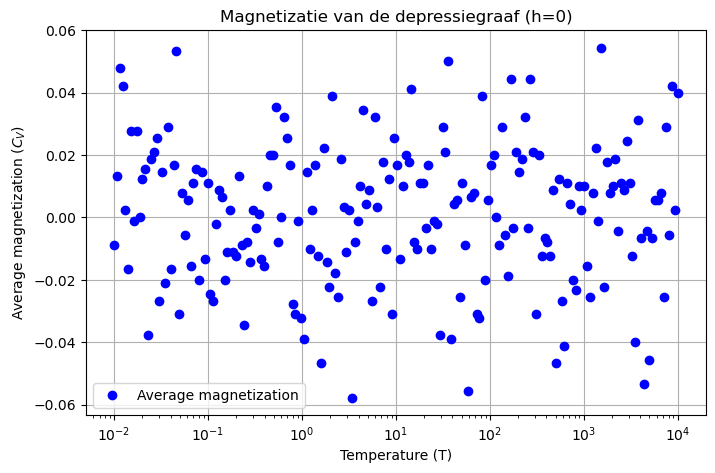

In [14]:
from matplotlib.pyplot import semilogy
magnetization = np.mean(averages, axis=1)
print(T_sweep)
plt.figure(figsize=(8, 5))
plt.semilogx(T_sweep, magnetization, 'bo', label='Average magnetization')
plt.xlabel('Temperature (T)')
plt.ylabel('Average magnetization ($C_V$)')
plt.title('Magnetizatie van de depressiegraaf (h=0)')
plt.legend()
plt.grid()
plt.show()